In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [3]:
DATA_PATH = Path(
    "../data/processed/demand_2026.parquet"
)

df = pd.read_parquet(DATA_PATH)

In [4]:
df.head()

,settlement_date,settlement_period,national_demand_mw,forecast_actual_indicator,transmission_system_demand_mw,england_wales_demand_mw,embedded_wind_generation_mw,embedded_wind_capacity_mw,embedded_solar_generation_mw,embedded_solar_capacity_mw,...,ifa2_flow,britned_flow,moyle_flow,east_west_flow,nemo_flow,nsl_flow,eleclink_flow,viking_flow,greenlink_flow,settlement_start
0,2026-01-01,1,25107,A,29668,23625,4146,6417,0,22300,...,-610,989,-361,-527,209,677,-352,1021,-513,2026-01-01 00:00:00+00:00
1,2026-01-01,2,25881,A,30361,24341,4188,6417,0,22300,...,-606,1005,-361,-453,243,648,-359,994,-514,2026-01-01 00:30:00+00:00
2,2026-01-01,3,25355,A,30681,23805,4085,6417,0,22300,...,-594,844,-361,-524,343,667,-754,994,-514,2026-01-01 01:00:00+00:00
3,2026-01-01,4,24762,A,30225,23226,4092,6417,0,22300,...,-589,837,-361,-531,346,650,-770,990,-514,2026-01-01 01:30:00+00:00
4,2026-01-01,5,24111,A,29092,22653,4044,6417,0,22300,...,-431,949,-361,-531,146,413,-475,990,-513,2026-01-01 02:00:00+00:00


In [5]:
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")

print(
    "Date range:",
    df["settlement_start"].min(),
    "to",
    df["settlement_start"].max(),
)

Rows: 12,190
Columns: 24
Date range: 2026-01-01 00:00:00+00:00 to 2026-09-11 23:30:00+01:00


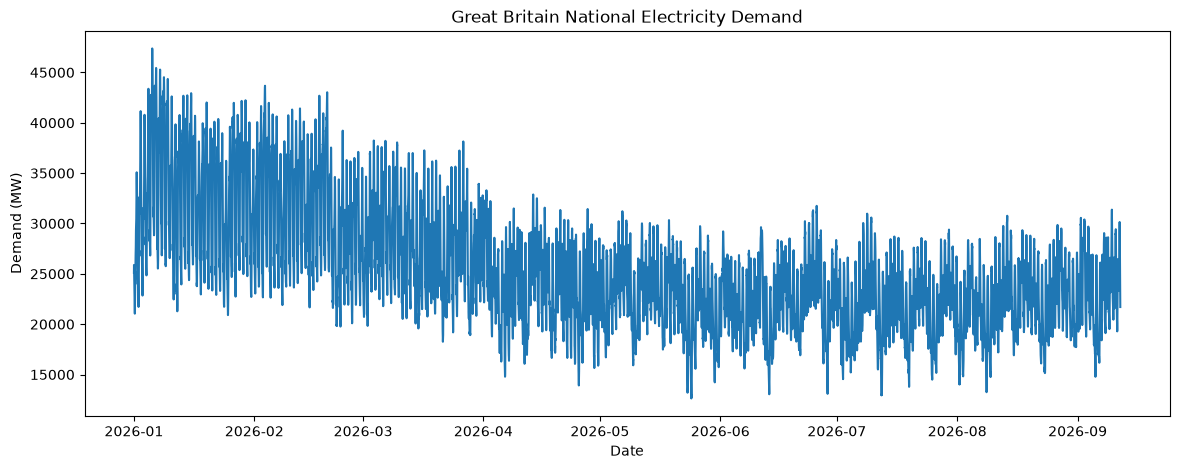

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df["settlement_start"],
    df["national_demand_mw"],
)

ax.set_title("Great Britain National Electricity Demand")
ax.set_xlabel("Date")
ax.set_ylabel("Demand (MW)")

plt.show()

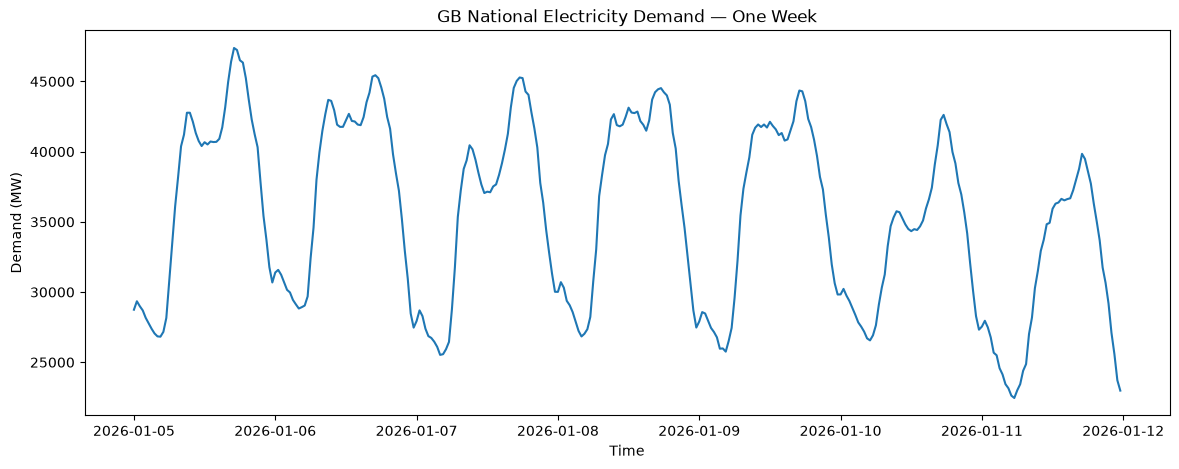

In [7]:
week = df[
    (df["settlement_start"] >= "2026-01-05")
    & (df["settlement_start"] < "2026-01-12")
]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    week["settlement_start"],
    week["national_demand_mw"],
)

ax.set_title(
    "GB National Electricity Demand — One Week"
)
ax.set_xlabel("Time")
ax.set_ylabel("Demand (MW)")

plt.show()

In [8]:
df["hour"] = (
    df["settlement_start"].dt.hour
    + df["settlement_start"].dt.minute / 60
)

df["day_of_week"] = (
    df["settlement_start"].dt.day_name()
)

df["month"] = (
    df["settlement_start"].dt.month_name()
)

In [10]:
demand_by_hour = (
    df.groupby("hour")["national_demand_mw"]
    .mean()
)
demand_by_hour.head(10)

hour
0.0    23590.767717
0.5    23533.299213
1.0    23227.786561
1.5    22908.549407
2.0    22475.669291
2.5    21996.519685
3.0    21530.330709
3.5    21175.688976
4.0    20860.862205
4.5    20697.440945
Name: national_demand_mw, dtype: float64

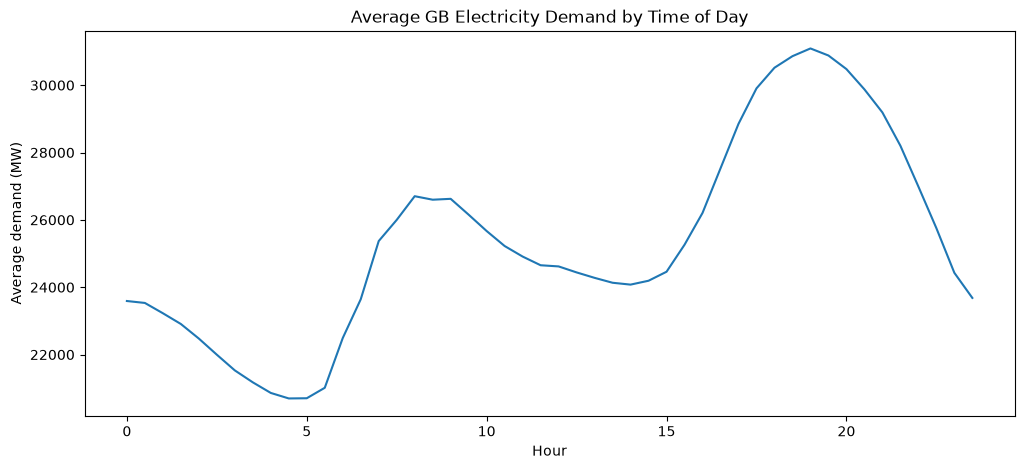

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    demand_by_hour.index,
    demand_by_hour.values,
)

ax.set_title("Average GB Electricity Demand by Time of Day")
ax.set_xlabel("Hour")
ax.set_ylabel("Average demand (MW)")

plt.show()

In [12]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

demand_by_weekday = (
    df.groupby("day_of_week")["national_demand_mw"]
    .mean()
    .reindex(weekday_order)
)

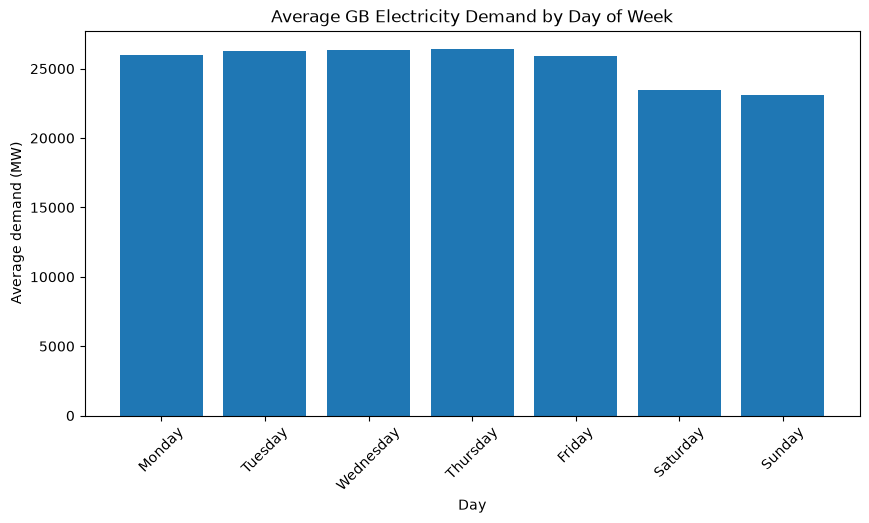

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    demand_by_weekday.index,
    demand_by_weekday.values,
)

ax.set_title("Average GB Electricity Demand by Day of Week")
ax.set_xlabel("Day")
ax.set_ylabel("Average demand (MW)")

plt.xticks(rotation=45)
plt.show()

In [14]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
]

demand_by_month = (
    df.groupby("month")["national_demand_mw"]
    .mean()
    .reindex(month_order)
)

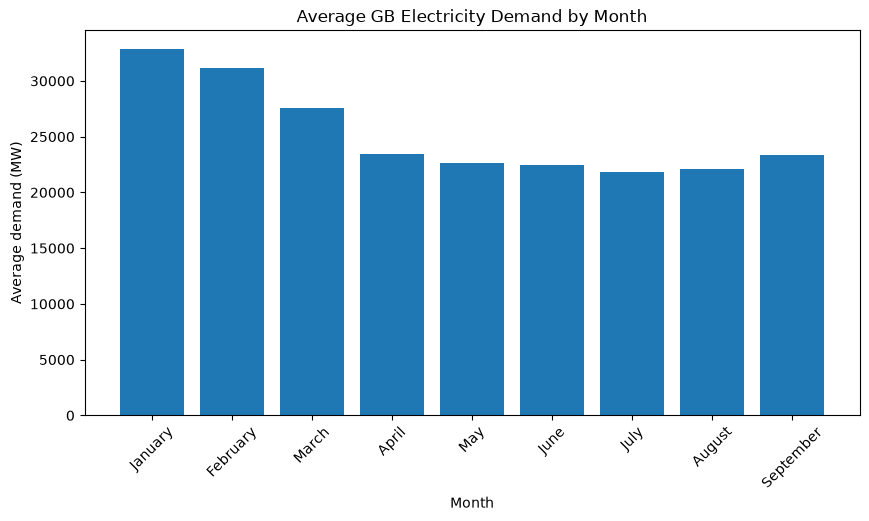

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    demand_by_month.index,
    demand_by_month.values,
)

ax.set_title("Average GB Electricity Demand by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Average demand (MW)")

plt.xticks(rotation=45)
plt.show()

In [16]:
df["is_weekend"] = (
    df["settlement_start"].dt.dayofweek >= 5
)

demand_profile = (
    df.groupby(["is_weekend", "hour"])
    ["national_demand_mw"]
    .mean()
    .reset_index()
)

weekday_profile = demand_profile[
    ~demand_profile["is_weekend"]
]

weekend_profile = demand_profile[
    demand_profile["is_weekend"]
]

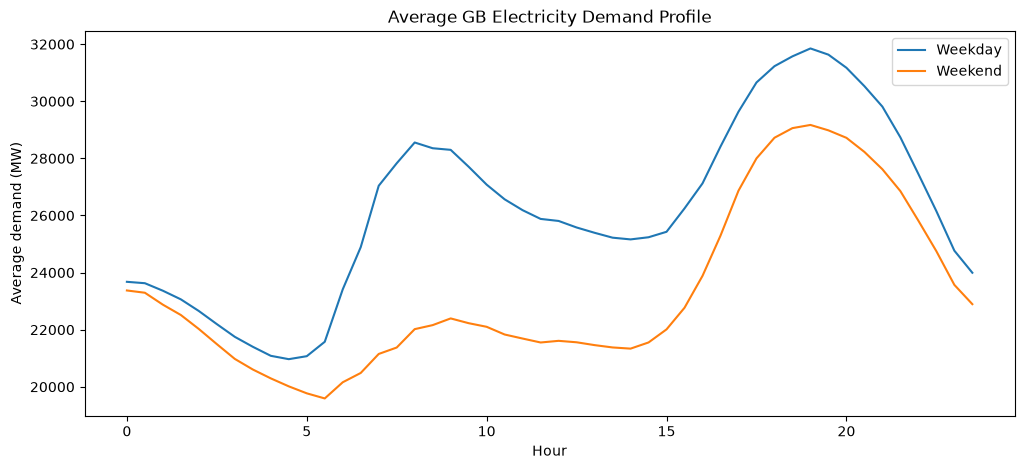

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    weekday_profile["hour"],
    weekday_profile["national_demand_mw"],
    label="Weekday",
)

ax.plot(
    weekend_profile["hour"],
    weekend_profile["national_demand_mw"],
    label="Weekend",
)

ax.set_title(
    "Average GB Electricity Demand Profile"
)
ax.set_xlabel("Hour")
ax.set_ylabel("Average demand (MW)")
ax.legend()

plt.show()